# Simulate Tax for all Portfolioa

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import pandas.tseries.offsets as pd_offsets
import pickle
import plotly.graph_objects as go
from typing import Dict, Tuple
from dateutil.relativedelta import relativedelta
import itertools

In [2]:
from utils.plots import (
    draw_growth_chart,
    draw_telltale_chart,
    draw_risk_reward_chart,
    draw_periodic_return,
)
from utils.plots import (
    draw_correlations,
    compare_portfolios,
    draw_max_portfolio_drawdowns,
    draw_min_portfolio_returns,
)
from utils.math import (
    gmean,
    calc_min_returns,
    calc_max_drawdown,
    calc_correlations_over_time,
    normalize,
    calc_returns,
)
from utils.math.cagr import cagr
from utils.math import to_float, calc_growth, normalize_df
from utils.data import cached, read_csv
from utils.portfolio import (
    Portfolio,
    Asset,
    GermanTaxModel,
    MAPortfolio,
    MATolPortfolio,
    MABBPortfolio,
)

In [3]:
clean_data_path = Path("clean_data")
cache_path = Path("cached_data")

In [4]:
input_path = clean_data_path / "etfs.xlsx"
etfs = pd.read_excel(input_path, index_col=0)
etfs.index = pd.to_datetime(etfs.index)
etfs["cash"] = 100.0
etfs

,1x_sp500_us,2x_sp500_us,3x_sp500_us,1x_sp500_eu,2x_sp500_eu,1x_ndx100_us,2x_ndx100_us,3x_ndx100_us,1x_ndx100_eu,2x_ndx100_eu,3x_ndx100_eu,cash
1927-12-30,99.999644,99.992264,99.993668,99.998985,9.999451e+01,9.999942e+01,9.999534e+01,99.993280,9.999800e+01,9.999727e+01,99.991049,100.0
1927-12-31,100.011317,100.008586,100.023422,100.009999,1.000131e+02,1.000109e+02,1.000147e+02,100.022647,1.000080e+02,1.000186e+02,100.018184,100.0
1928-01-01,100.023044,100.025015,100.053343,100.021067,1.000317e+02,1.000224e+02,1.000342e+02,100.052180,1.000181e+02,1.000400e+02,100.045483,100.0
1928-01-02,100.034772,100.041448,100.083273,100.032137,1.000504e+02,1.000339e+02,1.000537e+02,100.081722,1.000282e+02,1.000615e+02,100.072790,100.0
1928-01-03,100.612950,101.190855,101.813380,100.609641,1.012022e+02,1.006118e+02,1.012064e+02,101.811415,1.006047e+02,1.012161e+02,101.800096,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-13,906556.373424,708306.412828,324648.095145,717398.623168,1.571382e+06,2.861094e+06,6.528070e+06,216693.132413,1.722793e+06,1.295532e+07,98019.486705,100.0
2025-04-14,913794.010645,719484.330026,332331.395903,723121.363848,1.596216e+06,2.860647e+06,6.525047e+06,216530.633597,1.722499e+06,1.294957e+07,97943.794255,100.0
2025-04-15,912250.880413,716920.416244,330553.241029,721895.460622,1.590563e+06,2.887575e+06,6.646904e+06,222584.331509,1.738689e+06,1.319165e+07,100679.891548,100.0
2025-04-16,891844.360695,684712.793463,308276.373677,705742.325405,1.519143e+06,2.799753e+06,6.241585e+06,202212.734867,1.685784e+06,1.238750e+07,91463.114200,100.0


In [5]:
import plotly.express as px

window = 290

sp500_ta = etfs["1x_sp500_eu"].to_frame()

sp500_ta["ma"] = sp500_ta["1x_sp500_eu"].rolling(window=window).mean()
sp500_ta["std"] = sp500_ta["1x_sp500_eu"].rolling(window=window).std()
sp500_ta["bb_upper"] = sp500_ta["ma"] + 1.5 * sp500_ta["std"]
sp500_ta["bb_lower"] = sp500_ta["ma"] - 1.5 * sp500_ta["std"]

# sp500_ta
sp500_ta = sp500_ta.loc["2022-11-30":"2025-12-31"]

In [6]:
import plotly.graph_objects as go

price = sp500_ta["1x_sp500_eu"]
ma = sp500_ta["ma"]

cross_up = (price > ma) & (price.shift(1) <= ma.shift(1))
cross_down = (price < ma) & (price.shift(1) >= ma.shift(1))

cross_up_dates = sp500_ta.index[cross_up]
cross_down_dates = sp500_ta.index[cross_down]

# Build figure as before
fig = go.Figure(
    [
        go.Scatter(
            x=sp500_ta.index,
            y=sp500_ta["bb_upper"],
            line=dict(color="rgba(255,0,0,0.3)", width=0),
            showlegend=False,
            name="BB Upper",
        ),
        go.Scatter(
            x=sp500_ta.index,
            y=sp500_ta["bb_lower"],
            line=dict(color="rgba(255,0,0,0.3)", width=0),
            fill="tonexty",
            fillcolor="rgba(200,0,0,0.2)",
            showlegend=True,
            name="Bollinger Band",
        ),
        go.Scatter(
            x=sp500_ta.index,
            y=sp500_ta["1x_sp500_eu"],
            line=dict(color="blue"),
            name="Price",
        ),
        go.Scatter(
            x=sp500_ta.index,
            y=sp500_ta["ma"],
            line=dict(color="red", width=2),
            name="Moving Average",
        ),
    ]
)

# Add vertical lines for cross_up (green) and cross_down (red)
shapes = []
for date in cross_up_dates:
    shapes.append(
        dict(
            type="line",
            xref="x",
            yref="paper",
            x0=date,
            x1=date,
            y0=0,
            y1=1,
            line=dict(color="green", width=2, dash="dot"),
        )
    )
for date in cross_down_dates:
    shapes.append(
        dict(
            type="line",
            xref="x",
            yref="paper",
            x0=date,
            x1=date,
            y0=0,
            y1=1,
            line=dict(color="red", width=2, dash="dot"),
        )
    )

fig.update_layout(
    title="SP500 with Moving Average and Shaded Bollinger Bands", shapes=shapes
)
fig.show()


In [7]:
p_sp500 = Portfolio(
    {
        "1x_sp500_eu": 100.0,
    },
    start_value=1000,
    tax_model=GermanTaxModel(),
).backtest(etfs)

p_2x_sp500 = Portfolio(
    {
        "2x_sp500_eu": 100.0,
    },
    start_value=1000,
    tax_model=GermanTaxModel(),
).backtest(etfs)

p_2x_sp500_ma = MAPortfolio(
    {
        "2x_sp500_eu": dict(dist=100, ma=255, ma_asset="1x_sp500_eu"),
    },
    start_value=1000,
    tax_model=GermanTaxModel(),
    spread=0.002,
).backtest(etfs)

p_2x_sp500_ma_thrs = MATolPortfolio(
    {
        "2x_sp500_eu": dict(dist=100, ma=255, ma_asset="1x_sp500_eu"),
    },
    start_value=1000,
    tax_model=GermanTaxModel(),
    upper_tolerance=0.02,
    lower_tolerance=0.02,
    spread=0.002,
).backtest(etfs)

p_2x_sp500_ma_bb = MABBPortfolio(
    {
        "2x_sp500_eu": dict(dist=100, ma=255, ma_asset="1x_sp500_eu"),
    },
    start_value=1000,
    tax_model=GermanTaxModel(),
    upper_tolerance=2,
    lower_tolerance=2,
    spread=0.002,
).backtest(etfs)

p_2x_ndx100_ma = MAPortfolio(
    {
        "2x_ndx100_eu": dict(dist=100, ma=255, ma_asset="1x_ndx100_eu"),
    },
    start_value=1000,
    tax_model=GermanTaxModel(),
).backtest(etfs)

In [8]:
# p_2x_ndx100_2x_sp500_ma = MAPortfolio(
#     {
#         "2x_sp500_eu": dict(dist=80, ma=290, ma_asset="1x_sp500_eu"),
#         "2x_ndx100_eu": dict(dist=20, ma=310, ma_asset="1x_ndx100_eu"),
#     },
#     start_value=1000,
#     rebalancing=relativedelta(months=3),
#     rebalancing_offset=relativedelta(days=-8),
#     spread=0.002,
#     tax_model=GermanTaxModel(),
# ).backtest(etfs)

# p_2x_ndx100_2x_sp500_ma_sliced = p_2x_ndx100_2x_sp500_ma.loc["1945":"2025"]

In [ ]:
import optuna
import optunahub
from multiprocessing import Pool
import os

optuna.logging.set_verbosity(optuna.logging.WARNING)
samplers = optunahub.load_module(package="samplers/auto_sampler")

# --- USER CONFIGURATION ---
min_splits = 2  # Enforce at least 2: train+holdout
max_splits = 12
split_step = 1
n_trials = 50
n_repeat = 1
# --- END USER CONFIGURATION ---


def generate_k_folds(n_samples, n_folds):
    fold_size = n_samples // n_folds
    return [
        (i * fold_size, (i + 1) * fold_size if i < n_folds - 1 else n_samples)
        for i in range(n_folds)
    ]


def run_window_backtest(args):
    params, split_indices, price_data = args
    ma_period = params["ma_period"]
    action_threshold = params["action_threshold"]
    start, end = split_indices
    window_slice = price_data.iloc[start:end]
    dt_start, dt_end = window_slice.index[0], window_slice.index[-1]

    portfolio = MATolPortfolio(
        {"2x_sp500_eu": dict(dist=100, ma=ma_period, ma_asset="1x_sp500_eu")},
        start_value=1000,
        tax_model=GermanTaxModel(),
        upper_tolerance=action_threshold,
        lower_tolerance=action_threshold,
        spread=0.002,
    )
    performance = portfolio.backtest(price_data).loc[dt_start:dt_end]
    performance_cagr = cagr(performance)
    max_drawdown = abs(calc_max_drawdown(performance)[0]["sum"].item())
    calmar = performance_cagr / max_drawdown if max_drawdown > 0 else 0

    return {
        "calmar": calmar,
        "cagr": performance_cagr,
        "max_drawdown": -max_drawdown,
        "window": (dt_start, dt_end),
    }


def optuna_objective(trial, splits, price_data):
    ma_period = trial.suggest_int("ma_period", 150, 360)
    action_threshold = trial.suggest_float("action_threshold", 0.005, 0.05)
    params = {"ma_period": ma_period, "action_threshold": action_threshold}

    workers = min(len(splits), os.cpu_count() or 1)
    with Pool(workers) as pool:
        results = pool.map(
            run_window_backtest, [(params, s, price_data) for s in splits]
        )
    calmar_list = [res["calmar"] for res in results]
    cagr_list = [res["cagr"] for res in results]
    mdd_list = [res["max_drawdown"] for res in results]

    avg_calmar = float(np.mean(calmar_list)) if calmar_list else 0
    trial.set_user_attr("avg_calmar", avg_calmar)
    trial.set_user_attr("cagr_per_window", cagr_list)
    trial.set_user_attr("drawdown_per_window", mdd_list)
    trial.set_user_attr("ma_period", ma_period)
    trial.set_user_attr("action_threshold", action_threshold)
    trial.set_user_attr("calmar_per_window", calmar_list)
    return avg_calmar


all_results = {}
n_samples = len(etfs)

# --------- Main Loop with Holdout OOS Evaluation ---------
for n_folds in range(min_splits, max_splits + 1, split_step):
    splits = generate_k_folds(n_samples, n_folds)
    if n_folds < 2:
        print(f"n_folds={n_folds} < 2 (train+holdout), skipping...")
        continue
    train_splits = splits[:-1]
    holdout_split = splits[-1]

    print(
        f"\n=== Running {n_repeat} Optuna studies for n_folds={n_folds}, window_size~{splits[0][1] - splits[0][0]} ==="
    )

    best_params_collection = []
    best_train_values = []
    best_train_calmar_per_window = []
    best_train_cagr_win = []
    best_train_mdd_win = []
    best_oos_results = []  # for OOS per repeat

    for repeat in range(n_repeat):
        print(f"  Repeat {repeat + 1}/{n_repeat}...")

        # Only fit on training splits (N-1 windows)
        study = optuna.create_study(
            direction="maximize", sampler=samplers.AutoSampler()
        )
        study.optimize(
            lambda trial: optuna_objective(trial, train_splits, etfs),
            n_trials=n_trials,
            show_progress_bar=False,
        )
        best = study.best_trial
        best_params_collection.append(best.params)
        best_train_values.append(best.value)
        best_train_calmar_per_window.append(
            np.asarray(best.user_attrs["calmar_per_window"], dtype=float)
        )
        best_train_cagr_win.append(
            np.asarray(best.user_attrs["cagr_per_window"], dtype=float)
        )
        best_train_mdd_win.append(
            np.asarray(best.user_attrs["drawdown_per_window"], dtype=float)
        )

        # --- Evaluate OOS (holdout window) using CV-best params ---
        oos_result = run_window_backtest((best.params, holdout_split, etfs))
        best_oos_results.append(oos_result)

    # --- Aggregate stats ---
    avg_params = {
        k: float(np.mean([p[k] for p in best_params_collection]))
        for k in best_params_collection[0]
    }
    std_params = {
        k: float(np.std([p[k] for p in best_params_collection]))
        for k in best_params_collection[0]
    }
    avg_train_value = float(np.mean(best_train_values))
    std_train_value = float(np.std(best_train_values))
    avg_train_calmar_per_window = np.mean(
        np.vstack(best_train_calmar_per_window), axis=0
    )
    avg_cagr_per_window = np.mean(np.vstack(best_train_cagr_win), axis=0)
    avg_mdd_per_window = np.mean(np.vstack(best_train_mdd_win), axis=0)

    # OOS performance (averaged if n_repeat > 1)
    avg_oos_calmar = float(np.mean([r["calmar"] for r in best_oos_results]))
    avg_oos_cagr = float(np.mean([r["cagr"] for r in best_oos_results]))
    avg_oos_mdd = float(np.mean([r["max_drawdown"] for r in best_oos_results]))

    print(f"\n=== Averaged Best for n_folds={n_folds} ===")
    print(
        f"  Avg Train Calmar(mean {n_folds - 1} folds): {avg_train_value:.4f} (std {std_train_value:.4f})"
    )
    print(f"  Avg Params: {avg_params}")
    print(f"  Std of params: {std_params}")
    print(f"  Avg Train Calmar per window: {avg_train_calmar_per_window}")
    print(f"  Avg Train CAGR per window: {avg_cagr_per_window}")
    print(f"  Avg Train MaxDD per window: {avg_mdd_per_window}")
    print("---")
    print(f"  OOS Holdout Calmar (last window): {avg_oos_calmar:.4f}")
    print(f"  OOS Holdout CAGR (last window): {avg_oos_cagr:.4f}")
    print(f"  OOS Holdout MaxDD (last window): {avg_oos_mdd:.4f}")
    holdout_start, holdout_end = holdout_split
    print(
        f"  Holdout period: [{etfs.index[holdout_start]} - {etfs.index[holdout_end - 1]}]"
    )

    window_dates = [
        f"[{str(etfs.index[start])} - {str(etfs.index[end - 1])}]"
        if end > start
        else "[empty]"
        for start, end in splits
    ]
    print(f"n_folds={n_folds}: {', '.join(window_dates)}")

    all_results[n_folds] = {
        "avg_params": avg_params,
        "std_params": std_params,
        "avg_train_value": avg_train_value,
        "std_train_value": std_train_value,
        "avg_train_calmar_per_window": avg_train_calmar_per_window,
        "avg_train_cagr_per_window": avg_cagr_per_window,
        "avg_train_mdd_per_window": avg_mdd_per_window,
        "avg_oos_calmar": avg_oos_calmar,
        "avg_oos_cagr": avg_oos_cagr,
        "avg_oos_mdd": avg_oos_mdd,
        "holdout_period": (etfs.index[holdout_start], etfs.index[holdout_end - 1]),
        "splits": splits,
        "param_records": best_params_collection,
        "train_value_records": best_train_values,
        "oos_records": best_oos_results,
    }


=== Running 1 Optuna studies for n_folds=2, window_size~17769 ===
  Repeat 1/1...


/home/max/.cache/optunahub/api.github.com/optuna/optunahub-registry/main/package/samplers/auto_sampler/_sampler.py:184: ExperimentalWarning:

GPSampler is experimental (supported from v3.6.0). The interface can change in the future.




=== Averaged Best for n_folds=2 ===
  Avg Train Calmar(mean 1 folds): 0.2477 (std 0.0000)
  Avg Params: {'ma_period': 175.0, 'action_threshold': 0.005}
  Std of params: {'ma_period': 0.0, 'action_threshold': 0.0}
  Avg Train Calmar per window: [0.24770337]
  Avg Train CAGR per window: [0.15614654]
  Avg Train MaxDD per window: [-0.63037716]
---
  OOS Holdout Calmar (last window): 0.1092
  OOS Holdout CAGR (last window): 0.0861
  OOS Holdout MaxDD (last window): -0.7883
  Holdout period: [1976-08-23 00:00:00 - 2025-04-17 00:00:00]
n_folds=2: [1927-12-30 00:00:00 - 1976-08-22 00:00:00], [1976-08-23 00:00:00 - 2025-04-17 00:00:00]

=== Running 1 Optuna studies for n_folds=3, window_size~11846 ===
  Repeat 1/1...


/home/max/.cache/optunahub/api.github.com/optuna/optunahub-registry/main/package/samplers/auto_sampler/_sampler.py:184: ExperimentalWarning:

GPSampler is experimental (supported from v3.6.0). The interface can change in the future.




=== Averaged Best for n_folds=3 ===
  Avg Train Calmar(mean 2 folds): 0.2838 (std 0.0000)
  Avg Params: {'ma_period': 177.0, 'action_threshold': 0.005}
  Std of params: {'ma_period': 0.0, 'action_threshold': 0.0}
  Avg Train Calmar per window: [0.28330548 0.28437864]
  Avg Train CAGR per window: [0.18475277 0.11802639]
  Avg Train MaxDD per window: [-0.65213272 -0.41503252]
---
  OOS Holdout Calmar (last window): 0.1056
  OOS Holdout CAGR (last window): 0.0840
  OOS Holdout MaxDD (last window): -0.7954
  Holdout period: [1992-11-10 00:00:00 - 2025-04-17 00:00:00]
n_folds=3: [1927-12-30 00:00:00 - 1960-06-04 00:00:00], [1960-06-05 00:00:00 - 1992-11-09 00:00:00], [1992-11-10 00:00:00 - 2025-04-17 00:00:00]

=== Running 1 Optuna studies for n_folds=4, window_size~8884 ===
  Repeat 1/1...


...


=== Averaged Best for n_folds=10 ===
  Avg Train Calmar(mean 9 folds): 0.3773 (std 0.0000)
  Avg Params: {'ma_period': 253.0, 'action_threshold': 0.048867189576114835}
  Std of params: {'ma_period': 0.0, 'action_threshold': 0.0}
  Avg Train Calmar per window: [0.29134636 0.12455769 0.87186992 0.63464109 0.17205585 0.22536964
 0.36476999 0.2471936  0.46426469]
  Avg Train CAGR per window: [0.19059911 0.08607952 0.27611716 0.16363508 0.05049916 0.08060294
 0.16568873 0.12594635 0.15292646]
  Avg Train MaxDD per window: [-0.65420111 -0.69108158 -0.31669536 -0.25783877 -0.29350448 -0.35764774
 -0.45422797 -0.50950491 -0.32939499]
---
  OOS Holdout Calmar (last window): 0.2812
  OOS Holdout CAGR (last window): 0.1215
  OOS Holdout MaxDD (last window): -0.4319
  Holdout period: [2015-07-18 00:00:00 - 2025-04-17 00:00:00]
n_folds=10: [1927-12-30 00:00:00 - 1937-09-20 00:00:00], [1937-09-21 00:00:00 - 1947-06-13 00:00:00], [1947-06-14 00:00:00 - 1957-03-05 00:00:00], [1957-03-06 00:00:00 - 19

/home/max/.cache/optunahub/api.github.com/optuna/optunahub-registry/main/package/samplers/auto_sampler/_sampler.py:184: ExperimentalWarning:

GPSampler is experimental (supported from v3.6.0). The interface can change in the future.




=== Averaged Best for n_folds=11 ===
  Avg Train Calmar(mean 10 folds): 0.2835 (std 0.0000)
  Avg Params: {'ma_period': 265.0, 'action_threshold': 0.021307274805592493}
  Std of params: {'ma_period': 0.0, 'action_threshold': 0.0}
  Avg Train Calmar per window: [0.00168924 0.06833905 0.57177738 0.35414581 0.23817671 0.14069342
 0.33927124 0.55409299 0.1711255  0.39528998]
  Avg Train CAGR per window: [0.00137892 0.04406442 0.16679059 0.16109696 0.06521862 0.05818182
 0.1481421  0.20059721 0.06761806 0.12766947]
  Avg Train MaxDD per window: [-0.81629624 -0.64479119 -0.29170548 -0.45488879 -0.27382452 -0.4135362
 -0.43664797 -0.36202806 -0.39513725 -0.32297674]
---
  OOS Holdout Calmar (last window): 0.3861
  OOS Holdout CAGR (last window): 0.1687
  OOS Holdout MaxDD (last window): -0.4370
  Holdout period: [2016-06-05 00:00:00 - 2025-04-17 00:00:00]
n_folds=11: [1927-12-30 00:00:00 - 1936-11-01 00:00:00], [1936-11-02 00:00:00 - 1945-09-05 00:00:00], [1945-09-06 00:00:00 - 1954-07-10 00

/home/max/.cache/optunahub/api.github.com/optuna/optunahub-registry/main/package/samplers/auto_sampler/_sampler.py:184: ExperimentalWarning:

GPSampler is experimental (supported from v3.6.0). The interface can change in the future.




=== Averaged Best for n_folds=12 ===
  Avg Train Calmar(mean 11 folds): 0.3859 (std 0.0000)
  Avg Params: {'ma_period': 265.0, 'action_threshold': 0.02912342851086797}
  Std of params: {'ma_period': 0.0, 'action_threshold': 0.0}
  Avg Train Calmar per window: [0.09115147 0.06957087 0.75900169 0.74520619 0.38867882 0.10913192
 0.2514206  0.437521   0.62845602 0.10099019 0.66340091]
  Avg Train CAGR per window: [0.06605128 0.04524734 0.25837194 0.27536174 0.11273441 0.03855051
 0.08251294 0.19055004 0.22806555 0.03205244 0.18620042]
  Avg Train MaxDD per window: [-0.72463212 -0.65037764 -0.34041023 -0.36951081 -0.29004516 -0.3532469
 -0.32818689 -0.43552205 -0.3628982  -0.31738168 -0.28067556]
---
  OOS Holdout Calmar (last window): 0.4076
  OOS Holdout CAGR (last window): 0.1811
  OOS Holdout MaxDD (last window): -0.4442
  Holdout period: [2017-03-03 00:00:00 - 2025-04-17 00:00:00]
n_folds=12: [1927-12-30 00:00:00 - 1936-02-06 00:00:00], [1936-02-07 00:00:00 - 1944-03-16 00:00:00], [19

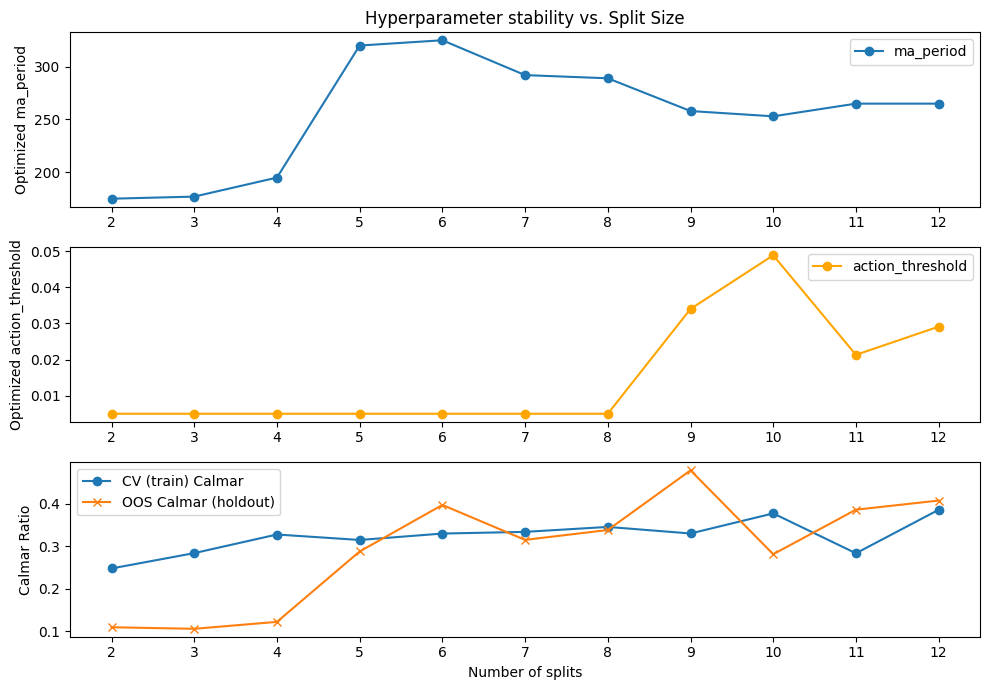

----- Hyperparameter stability metrics -----
ma_period   : stdev=50.40, range=150.00
action_thresh: stdev=0.01491, range=0.04387


In [11]:
import matplotlib.pyplot as plt
import numpy as np

split_sizes = []
ma_periods = []
action_thresholds = []
avg_train_calmars = []
oos_calmars = []

for n_splits, res in sorted(all_results.items()):
    split_sizes.append(n_splits)
    ma_periods.append(res["avg_params"]["ma_period"])
    action_thresholds.append(res["avg_params"]["action_threshold"])
    avg_train_calmars.append(res["avg_train_value"])
    oos_calmars.append(res["avg_oos_calmar"])

plt.figure(figsize=(10, 7))

plt.subplot(3, 1, 1)
plt.plot(split_sizes, ma_periods, marker="o", label="ma_period")
plt.ylabel("Optimized ma_period")
plt.xticks(split_sizes)
plt.legend()
plt.title("Hyperparameter stability vs. Split Size")

plt.subplot(3, 1, 2)
plt.plot(
    split_sizes, action_thresholds, marker="o", color="orange", label="action_threshold"
)
plt.ylabel("Optimized action_threshold")
plt.xticks(split_sizes)
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(split_sizes, avg_train_calmars, label="CV (train) Calmar", marker="o")
plt.plot(split_sizes, oos_calmars, label="OOS Calmar (holdout)", marker="x")
plt.ylabel("Calmar Ratio")
plt.xlabel("Number of splits")
plt.xticks(split_sizes)
plt.legend()

plt.tight_layout()
plt.show()

# Print stability metrics
print("----- Hyperparameter stability metrics -----")
print(f"ma_period   : stdev={np.std(ma_periods):.2f}, range={np.ptp(ma_periods):.2f}")
print(
    f"action_thresh: stdev={np.std(action_thresholds):.5f}, range={np.ptp(action_thresholds):.5f}"
)


### ToDo
More Trial! e.g. 250

FÜr unterschiedliche Windows ausprobieren, 10, 12, 14, 16, 18, 20 etc.
Beobachten: Wie stark verändern sich die Parameter (differenz) zum vorherigen window? 
Sollte stabil sein.

In [ ]:
start_date = "1945"
end_date = "2025"
portfolios = {}
short_names = []

# portfolios['50%'] = p_base.loc[start_date:end_date]
# short_names.append('50%')
# portfolios['50%+G'] = p_g.loc[start_date:end_date]
# short_names.append('50%+G')
# portfolios['50%+N'] = p_n.loc[start_date:end_date]
# short_names.append('50%+N')
# portfolios['50%+NG'] = p_ng.loc[start_date:end_date]
# short_names.append('50%+NG')

# portfolios['50%+MA'] = p_base_ma.loc[start_date:end_date]
# short_names.append('50%+MA')
# portfolios['50%+N+MA'] = p_n_ma.loc[start_date:end_date]
# short_names.append('50%+N+MA')
# portfolios['50%+NG+MA'] = p_ng_ma.loc[start_date:end_date]
# short_names.append('50%+NG+MA')

# portfolios['HFEA'] = p_hfea.loc[start_date:end_date]
# short_names.append('HFEA')

portfolios["S&P500"] = p_sp500.loc[start_date:end_date]
short_names.append("S&P500")

portfolios["2x S&P500"] = p_2x_sp500.loc[start_date:end_date]
short_names.append("2x S&P500")

portfolios["2x S&P500 (MA)"] = p_2x_sp500_ma.loc[start_date:end_date]
short_names.append("2x S&P500 (MA)")

portfolios["2x S&P500 (THRS)"] = p_2x_sp500_ma_thrs.loc[start_date:end_date]
short_names.append("2x S&P500 (THRS)")

portfolios["2x S&P500 (BB)"] = p_2x_sp500_ma_bb.loc[start_date:end_date]
short_names.append("2x S&P500 (BB)")
portfolios["2x NS100 (MA)"] = p_2x_ndx100_ma.loc[start_date:end_date]
short_names.append("2x NS100 (MA)")

# portfolios["2x NS100+S&P500 (MA)"] = p_2x_ndx100_2x_sp500_ma.loc[start_date:end_date]
# short_names.append("2x NS100&SP500 (MA)")
# portfolios['P'] = p_pari.loc[start_date:end_date]
# short_names.append('P')

for v in portfolios.values():
    v = normalize_df(v, start_value=1000)

compare_portfolios(
    portfolios,
    short_names=short_names,
    details=True,
)

## 65% Portfolio

In [ ]:
# p_base = MAPortfolio(
#     {
#         '2x_sp500_eu': dict(dist=65),
#         '1x_ltt_eu': dict(dist=35),
#     },
#     start_value = 1000,
#     rebalancing = relativedelta(months=3),
#     rebalancing_offset = relativedelta(days=-8),
#     spread = 0.002,
#     tax_model=GermanTaxModel(),
# ).backtest(etfs)

# p_g = MAPortfolio(
#     {
#         '2x_sp500_eu': dict(dist=65),
#         '1x_ltt_eu': dict(dist=26.25),
#         '1x_gold_eu': dict(dist=8.75),
#     },
#     start_value = 1000,
#     rebalancing = relativedelta(months=3),
#     rebalancing_offset = relativedelta(days=-8),
#     spread = 0.002,
#     tax_model=GermanTaxModel(),
# ).backtest(etfs)

# p_n = MAPortfolio(
#     {
#         '2x_sp500_eu': dict(dist=55.25),
#         '2x_ndx100_eu': dict(dist=9.75),
#         '1x_ltt_eu': dict(dist=35),
#     },
#     start_value = 1000,
#     rebalancing = relativedelta(months=3),
#     rebalancing_offset = relativedelta(days=-8),
#     spread = 0.002,
#     tax_model=GermanTaxModel(),
# ).backtest(etfs)

# #p_ng = MAPortfolio(
# #    {
# #        '2x_sp500_eu': dict(dist=42.5),
# #        '2x_ndx100_eu': dict(dist=7.5),
# #        '1x_ltt_eu': dict(dist=37.5),
# #        '1x_gold_eu': dict(dist=12.5),
# #    },
# #    start_value = 1000,
# #    rebalancing = relativedelta(months=3),
# #    rebalancing_offset = relativedelta(days=-8),
# #    spread = 0.002,
# #    tax_model=GermanTaxModel(),
# #).backtest(etfs)

# p_base_ma = MAPortfolio(
#     {
#         '2x_sp500_eu': dict(dist=65, ma=290, ma_asset="1x_sp500_eu"),
#         '1x_ltt_eu': dict(dist=35, ma=130, ma_asset="1x_ltt_eu"),
#     },
#     start_value = 1000,
#     rebalancing = relativedelta(months=3),
#     rebalancing_offset = relativedelta(days=-6),
#     spread = 0.002,
#     tax_model=GermanTaxModel(),
# ).backtest(etfs)

# p_n_ma = MAPortfolio(
#     {
#         '2x_sp500_eu': dict(dist=55.25, ma=290, ma_asset="1x_sp500_eu"),
#         '2x_ndx100_eu': dict(dist=9.75, ma=310, ma_asset="1x_ndx100_eu"),
#         '1x_ltt_eu': dict(dist=35, ma=130, ma_asset="1x_ltt_eu"),
#     },
#     start_value = 1000,
#     rebalancing = relativedelta(months=3),
#     rebalancing_offset = relativedelta(days=-8),
#     spread = 0.002,
#     tax_model=GermanTaxModel(),
# ).backtest(etfs)

# #p_ng_ma = MAPortfolio(
# #    {
# #        '2x_sp500_eu': dict(dist=42.5, ma=290, ma_asset="1x_sp500_eu"),
# #        '2x_ndx100_eu': dict(dist=7.5, ma=310, ma_asset="1x_ndx100_eu"),
# #        '1x_ltt_eu': dict(dist=37.5, ma=130, ma_asset="1x_ltt_eu"),
# #        '1x_gold_eu': dict(dist=12.5, ma=400, ma_asset="1x_gold_eu"),
# #    },
# #    start_value = 1000,
# #    rebalancing = relativedelta(months=3),
# #    rebalancing_offset = relativedelta(days=-8),
# #    spread = 0.002,
# #    tax_model=GermanTaxModel(),
# #).backtest(etfs)

In [ ]:
# start_date = '1944'
# end_date = '2021'
# portfolios = {}
# short_names = []

# portfolios['65%'] = p_base.loc[start_date:end_date]
# short_names.append('65%')
# portfolios['65%+G'] = p_g.loc[start_date:end_date]
# short_names.append('65%+G')
# portfolios['65%+N'] = p_n.loc[start_date:end_date]
# short_names.append('65%+N')
# #portfolios['50%+NG'] = p_ng.loc[start_date:end_date]
# #short_names.append('65%+NG')

# portfolios['65%+MA'] = p_base_ma.loc[start_date:end_date]
# short_names.append('65%+MA')
# portfolios['65%+N+MA'] = p_n_ma.loc[start_date:end_date]
# short_names.append('65%+N+MA')
# #portfolios['65%+NG+MA'] = p_ng_ma.loc[start_date:end_date]
# #short_names.append('65%+NG+MA')

# portfolios['HFEA'] = p_hfea.loc[start_date:end_date]
# short_names.append('HFEA')
# portfolios['S&P500'] = p_sp500.loc[start_date:end_date]
# short_names.append('S&P500')
# portfolios['2x S&P500'] = p_2x_sp500.loc[start_date:end_date]
# short_names.append('2x S&P500')
# portfolios['2x S&P500 (MA)'] = p_2x_sp500_ma.loc[start_date:end_date]
# short_names.append('2x S&P500 (MA)')
# portfolios['P'] = p_pari.loc[start_date:end_date]
# short_names.append('P')

# for v in portfolios.values():
#     v = normalize_df(v, start_value = 1000)

# compare_portfolios(
#     portfolios,
#     short_names = short_names,
#     details=True,
# )

## 80% Portfolio

In [ ]:
# p_base = MAPortfolio(
#     {
#         '2x_sp500_eu': dict(dist=80),
#         '1x_ltt_eu': dict(dist=20),
#     },
#     start_value = 1000,
#     rebalancing = relativedelta(months=3),
#     rebalancing_offset = relativedelta(days=-8),
#     spread = 0.002,
#     tax_model=GermanTaxModel(),
# ).backtest(etfs)

# p_g = MAPortfolio(
#     {
#         '2x_sp500_eu': dict(dist=80),
#         '1x_ltt_eu': dict(dist=15),
#         '1x_gold_eu': dict(dist=5),
#     },
#     start_value = 1000,
#     rebalancing = relativedelta(months=3),
#     rebalancing_offset = relativedelta(days=-8),
#     spread = 0.002,
#     tax_model=GermanTaxModel(),
# ).backtest(etfs)

# p_n = MAPortfolio(
#     {
#         '2x_sp500_eu': dict(dist=68),
#         '2x_ndx100_eu': dict(dist=12),
#         '1x_ltt_eu': dict(dist=20),
#     },
#     start_value = 1000,
#     rebalancing = relativedelta(months=3),
#     rebalancing_offset = relativedelta(days=-8),
#     spread = 0.002,
#     tax_model=GermanTaxModel(),
# ).backtest(etfs)

# p_ng = MAPortfolio(
#     {
#         '2x_sp500_eu': dict(dist=68),
#         '2x_ndx100_eu': dict(dist=12),
#         '1x_ltt_eu': dict(dist=15),
#         '1x_gold_eu': dict(dist=5),
#     },
#     start_value = 1000,
#     rebalancing = relativedelta(months=3),
#     rebalancing_offset = relativedelta(days=-8),
#     spread = 0.002,
#     tax_model=GermanTaxModel(),
# ).backtest(etfs)

# p_base_ma = MAPortfolio(
#     {
#         '2x_sp500_eu': dict(dist=80, ma=290, ma_asset="1x_sp500_eu"),
#         '1x_ltt_eu': dict(dist=20, ma=130, ma_asset="1x_ltt_eu"),
#     },
#     start_value = 1000,
#     rebalancing = relativedelta(months=3),
#     rebalancing_offset = relativedelta(days=-6),
#     spread = 0.002,
#     tax_model=GermanTaxModel(),
# ).backtest(etfs)

# p_n_ma = MAPortfolio(
#     {
#         '2x_sp500_eu': dict(dist=68, ma=290, ma_asset="1x_sp500_eu"),
#         '2x_ndx100_eu': dict(dist=12, ma=310, ma_asset="1x_ndx100_eu"),
#         '1x_ltt_eu': dict(dist=20, ma=130, ma_asset="1x_ltt_eu"),
#     },
#     start_value = 1000,
#     rebalancing = relativedelta(months=3),
#     rebalancing_offset = relativedelta(days=-8),
#     spread = 0.002,
#     tax_model=GermanTaxModel(),
# ).backtest(etfs)

# p_ng_ma = MAPortfolio(
#     {
#         '2x_sp500_eu': dict(dist=68, ma=290, ma_asset="1x_sp500_eu"),
#         '2x_ndx100_eu': dict(dist=12, ma=310, ma_asset="1x_ndx100_eu"),
#         '1x_ltt_eu': dict(dist=15, ma=130, ma_asset="1x_ltt_eu"),
#         '1x_gold_eu': dict(dist=5, ma=400, ma_asset="1x_gold_eu"),
#     },
#     start_value = 1000,
#     rebalancing = relativedelta(months=3),
#     rebalancing_offset = relativedelta(days=-8),
#     spread = 0.002,
#     tax_model=GermanTaxModel(),
# ).backtest(etfs)

In [ ]:
# start_date = '1944'
# end_date = '2021'
# portfolios = {}
# short_names = []

# portfolios['80%'] = p_base.loc[start_date:end_date]
# short_names.append('80%')
# portfolios['80%+G'] = p_g.loc[start_date:end_date]
# short_names.append('80%+G')
# portfolios['80%+N'] = p_n.loc[start_date:end_date]
# short_names.append('80%+N')
# portfolios['80%+NG'] = p_ng.loc[start_date:end_date]
# short_names.append('80%+NG')

# portfolios['80%+MA'] = p_base_ma.loc[start_date:end_date]
# short_names.append('80%+MA')
# portfolios['80%+N+MA'] = p_n_ma.loc[start_date:end_date]
# short_names.append('80%+N+MA')
# portfolios['80%+NG+MA'] = p_ng_ma.loc[start_date:end_date]
# short_names.append('80%+NG+MA')

# portfolios['HFEA'] = p_hfea.loc[start_date:end_date]
# short_names.append('HFEA')
# portfolios['S&P500'] = p_sp500.loc[start_date:end_date]
# short_names.append('S&P500')
# portfolios['2x S&P500'] = p_2x_sp500.loc[start_date:end_date]
# short_names.append('2x S&P500')
# portfolios['2x S&P500 (MA)'] = p_2x_sp500_ma.loc[start_date:end_date]
# short_names.append('2x S&P500 (MA)')
# portfolios['P'] = p_pari.loc[start_date:end_date]
# short_names.append('P')

# for v in portfolios.values():
#     v = normalize_df(v, start_value = 1000)

# compare_portfolios(
#     portfolios,
#     short_names = short_names,
#     details=True,
# )

## 65% (3x) Portfolio

In [ ]:
# p_base = MAPortfolio(
#     {
#         '3x_sp500_eu': dict(dist=65),
#         '3x_itt_eu': dict(dist=35),
#     },
#     start_value = 1000,
#     rebalancing = relativedelta(months=3),
#     rebalancing_offset = relativedelta(days=-8),
#     spread = 0.002,
#     tax_model=GermanTaxModel(),
# ).backtest(etfs)

# p_g = MAPortfolio(
#     {
#         '3x_sp500_eu': dict(dist=65),
#         '3x_itt_eu': dict(dist=26.25),
#         '1x_gold_eu': dict(dist=8.75),
#     },
#     start_value = 1000,
#     rebalancing = relativedelta(months=3),
#     rebalancing_offset = relativedelta(days=-8),
#     spread = 0.002,
#     tax_model=GermanTaxModel(),
# ).backtest(etfs)

# p_n = MAPortfolio(
#     {
#         '3x_sp500_eu': dict(dist=55.25),
#         '3x_ndx100_eu': dict(dist=9.75),
#         '3x_itt_eu': dict(dist=35),
#     },
#     start_value = 1000,
#     rebalancing = relativedelta(months=3),
#     rebalancing_offset = relativedelta(days=-8),
#     spread = 0.002,
#     tax_model=GermanTaxModel(),
# ).backtest(etfs)

# #p_ng = MAPortfolio(
# #    {
# #        '2x_sp500_eu': dict(dist=68),
# #        '2x_ndx100_eu': dict(dist=12),
# #        '1x_ltt_eu': dict(dist=15),
# #        '1x_gold_eu': dict(dist=5),
# #    },
# #    start_value = 1000,
# #    rebalancing = relativedelta(months=3),
# #    rebalancing_offset = relativedelta(days=-8),
# #    spread = 0.002,
# #    tax_model=GermanTaxModel(),
# #).backtest(etfs)

# p_base_ma = MAPortfolio(
#     {
#         '3x_sp500_eu': dict(dist=65, ma=290, ma_asset="1x_sp500_eu"),
#         '3x_itt_eu': dict(dist=35, ma=70, ma_asset="1x_itt_eu"),
#     },
#     start_value = 1000,
#     rebalancing = relativedelta(months=3),
#     rebalancing_offset = relativedelta(days=-6),
#     spread = 0.002,
#     tax_model=GermanTaxModel(),
# ).backtest(etfs)

# p_n_ma = MAPortfolio(
#     {
#         '3x_sp500_eu': dict(dist=55.25, ma=290, ma_asset="1x_sp500_eu"),
#         '3x_ndx100_eu': dict(dist=9.75, ma=310, ma_asset="1x_ndx100_eu"),
#         '3x_itt_eu': dict(dist=35, ma=70, ma_asset="1x_itt_eu"),
#     },
#     start_value = 1000,
#     rebalancing = relativedelta(months=3),
#     rebalancing_offset = relativedelta(days=-8),
#     spread = 0.002,
#     tax_model=GermanTaxModel(),
# ).backtest(etfs)

# #p_ng_ma = MAPortfolio(
# #    {
# #        '2x_sp500_eu': dict(dist=68, ma=290, ma_asset="1x_sp500_eu"),
# #        '2x_ndx100_eu': dict(dist=12, ma=310, ma_asset="1x_ndx100_eu"),
# #        '1x_ltt_eu': dict(dist=15, ma=130, ma_asset="1x_ltt_eu"),
# #        '1x_gold_eu': dict(dist=5, ma=400, ma_asset="1x_gold_eu"),
# #    },
# #    start_value = 1000,
# #    rebalancing = relativedelta(months=3),
# #    rebalancing_offset = relativedelta(days=-8),
# #    spread = 0.002,
# #    tax_model=GermanTaxModel(),
# #).backtest(etfs)

In [ ]:
# start_date = '1944'
# end_date = '2021'
# portfolios = {}
# short_names = []

# portfolios['65% (3x)'] = p_base.loc[start_date:end_date]
# short_names.append('65% (3x)')
# portfolios['65%+G (3x)'] = p_g.loc[start_date:end_date]
# short_names.append('65%+G (3x)')
# portfolios['65%+N (3x)'] = p_n.loc[start_date:end_date]
# short_names.append('65%+N (3x)')
# #portfolios['80%+NG'] = p_ng.loc[start_date:end_date]
# #short_names.append('80%+NG')

# portfolios['65%+MA (3x)'] = p_base_ma.loc[start_date:end_date]
# short_names.append('65%+MA (3x)')
# portfolios['65%+N+MA (3x)'] = p_n_ma.loc[start_date:end_date]
# short_names.append('65%+N+MA (3x)')
# #portfolios['80%+NG+MA'] = p_ng_ma.loc[start_date:end_date]
# #short_names.append('80%+NG+MA')

# portfolios['HFEA'] = p_hfea.loc[start_date:end_date]
# short_names.append('HFEA')
# portfolios['S&P500'] = p_sp500.loc[start_date:end_date]
# short_names.append('S&P500')
# portfolios['2x S&P500'] = p_2x_sp500.loc[start_date:end_date]
# short_names.append('2x S&P500')
# portfolios['2x S&P500 (MA)'] = p_2x_sp500_ma.loc[start_date:end_date]
# short_names.append('2x S&P500 (MA)')
# portfolios['P'] = p_pari.loc[start_date:end_date]
# short_names.append('P')

# for v in portfolios.values():
#     v = normalize_df(v, start_value = 1000)

# compare_portfolios(
#     portfolios,
#     short_names = short_names,
#     details=True,
# )

## HFEA

In [ ]:
# p_base = MAPortfolio(
#     {
#         '3x_sp500_us': dict(dist=55),
#         '3x_ltt_us': dict(dist=45),
#     },
#     start_value = 1000,
#     rebalancing = relativedelta(months=3),
#     rebalancing_offset = relativedelta(days=-8),
#     spread = 0.002,
#     tax_model=GermanTaxModel(),
# ).backtest(etfs)

# p_g = MAPortfolio(
#     {
#         '3x_sp500_us': dict(dist=55),
#         '3x_ltt_us': dict(dist=33.75),
#         '1x_gold_eu': dict(dist=11.25),
#     },
#     start_value = 1000,
#     rebalancing = relativedelta(months=3),
#     rebalancing_offset = relativedelta(days=-8),
#     spread = 0.002,
#     tax_model=GermanTaxModel(),
# ).backtest(etfs)

# p_n = MAPortfolio(
#     {
#         '3x_sp500_us': dict(dist=41.25),
#         '3x_ndx100_us': dict(dist=13.75),
#         '3x_ltt_us': dict(dist=45),
#     },
#     start_value = 1000,
#     rebalancing = relativedelta(months=3),
#     rebalancing_offset = relativedelta(days=-8),
#     spread = 0.002,
#     tax_model=GermanTaxModel(),
# ).backtest(etfs)

# p_ng = MAPortfolio(
#     {
#         '3x_sp500_us': dict(dist=41.25),
#         '3x_ndx100_us': dict(dist=13.75),
#         '3x_ltt_us': dict(dist=38.25),
#         '1x_gold_eu': dict(dist=6.75),
#     },
#     start_value = 1000,
#     rebalancing = relativedelta(months=3),
#     rebalancing_offset = relativedelta(days=-8),
#     spread = 0.002,
#     tax_model=GermanTaxModel(),
# ).backtest(etfs)

# p_base_ma = MAPortfolio(
#     {
#         '3x_sp500_us': dict(dist=55, ma=290, ma_asset="1x_sp500_us"),
#         '3x_ltt_us': dict(dist=45, ma=130, ma_asset="1x_ltt_us"),
#     },
#     start_value = 1000,
#     rebalancing = relativedelta(months=3),
#     rebalancing_offset = relativedelta(days=-6),
#     spread = 0.002,
#     tax_model=GermanTaxModel(),
# ).backtest(etfs)

# p_n_ma = MAPortfolio(
#     {
#         '3x_sp500_us': dict(dist=41.25, ma=290, ma_asset="1x_sp500_us"),
#         '3x_ndx100_us': dict(dist=13.75, ma=310, ma_asset="1x_ndx100_us"),
#         '3x_ltt_us': dict(dist=45, ma=130, ma_asset="1x_ltt_us"),
#     },
#     start_value = 1000,
#     rebalancing = relativedelta(months=3),
#     rebalancing_offset = relativedelta(days=-8),
#     spread = 0.002,
#     tax_model=GermanTaxModel(),
# ).backtest(etfs)

# p_ng_ma = MAPortfolio(
#     {
#         '3x_sp500_us': dict(dist=41.25, ma=290, ma_asset="1x_sp500_us"),
#         '3x_ndx100_us': dict(dist=13.75, ma=310, ma_asset="1x_ndx100_us"),
#         '3x_ltt_us': dict(dist=38.25, ma=130, ma_asset="1x_ltt_us"),
#         '1x_gold_eu': dict(dist=6.75, ma=400, ma_asset="1x_gold_eu"),
#     },
#     start_value = 1000,
#     rebalancing = relativedelta(months=3),
#     rebalancing_offset = relativedelta(days=-8),
#     spread = 0.002,
#     tax_model=GermanTaxModel(),
# ).backtest(etfs)

In [ ]:
# start_date = '1944'
# end_date = '2021'
# portfolios = {}
# short_names = []

# portfolios['HFEA'] = p_base.loc[start_date:end_date]
# short_names.append('HFEA')
# portfolios['HFEA+G'] = p_g.loc[start_date:end_date]
# short_names.append('HFEA+G')
# portfolios['HFEA+N'] = p_n.loc[start_date:end_date]
# short_names.append('HFEA+N')
# portfolios['HFEA+NG'] = p_ng.loc[start_date:end_date]
# short_names.append('HFEA+NG')

# portfolios['HFEA+MA'] = p_base_ma.loc[start_date:end_date]
# short_names.append('HFEA+MA')
# portfolios['HFEA+N+MA'] = p_n_ma.loc[start_date:end_date]
# short_names.append('HFEA+N+MA')
# portfolios['HFEA+NG+MA'] = p_ng_ma.loc[start_date:end_date]
# short_names.append('HFEA+NG+MA')

# #portfolios['HFEA'] = p_hfea.loc[start_date:end_date]
# #short_names.append('HFEA')
# portfolios['S&P500'] = p_sp500.loc[start_date:end_date]
# short_names.append('S&P500')
# portfolios['2x S&P500'] = p_2x_sp500.loc[start_date:end_date]
# short_names.append('2x S&P500')
# portfolios['2x S&P500 (MA)'] = p_2x_sp500_ma.loc[start_date:end_date]
# short_names.append('2x S&P500 (MA)')
# portfolios['3x S&P500 (MA)'] = p_3x_sp500_ma.loc[start_date:end_date]
# short_names.append('3x S&P500 (MA)')
# portfolios['2x NDX100 (MA)'] = p_2x_ndx100_ma.loc[start_date:end_date]
# short_names.append('2x NDX100 (MA)')
# portfolios['3x NDX100 (MA)'] = p_3x_ndx100_ma.loc[start_date:end_date]
# short_names.append('3x NDX100 (MA)')
# portfolios['P'] = p_pari.loc[start_date:end_date]
# short_names.append('P')

# for v in portfolios.values():
#     v = normalize_df(v, start_value = 1000)

# compare_portfolios(
#     portfolios,
#     short_names = short_names,
#     details=True,
# )

## Comparison (Non-Tax)

In [ ]:
allocations = [
    (
        "2x S&P 500",
        ("2x_sp500_eu", 100),
        ("2x_ndx100_eu", 0),
        ("1x_ltt_eu", 0),
        ("1x_gold_eu", 0),
    ),
    (
        "50%",
        ("2x_sp500_eu", 50),
        ("2x_ndx100_eu", 0),
        ("1x_ltt_eu", 50),
        ("1x_gold_eu", 0),
    ),
    (
        "50%+G",
        ("2x_sp500_eu", 50),
        ("2x_ndx100_eu", 0),
        ("1x_ltt_eu", 37.5),
        ("1x_gold_eu", 12.5),
    ),
    (
        "50%+N",
        ("2x_sp500_eu", 42.5),
        ("2x_ndx100_eu", 7.5),
        ("1x_ltt_eu", 50),
        ("1x_gold_eu", 0),
    ),
    (
        "50%+NG",
        ("2x_sp500_eu", 42.5),
        ("2x_ndx100_eu", 7.5),
        ("1x_ltt_eu", 37.50),
        ("1x_gold_eu", 12.5),
    ),
    (
        "65%",
        ("2x_sp500_eu", 65),
        ("2x_ndx100_eu", 0),
        ("1x_ltt_eu", 35),
        ("1x_gold_eu", 0),
    ),
    (
        "65%+G",
        ("2x_sp500_eu", 65),
        ("2x_ndx100_eu", 0),
        ("1x_ltt_eu", 26.25),
        ("1x_gold_eu", 8.75),
    ),
    (
        "65%+N",
        ("2x_sp500_eu", 55.25),
        ("2x_ndx100_eu", 9.75),
        ("1x_ltt_eu", 35),
        ("1x_gold_eu", 0),
    ),
    (
        "80%",
        ("2x_sp500_eu", 80),
        ("2x_ndx100_eu", 0),
        ("1x_ltt_eu", 20),
        ("1x_gold_eu", 0),
    ),
    (
        "80%+G",
        ("2x_sp500_eu", 80),
        ("2x_ndx100_eu", 0),
        ("1x_ltt_eu", 15),
        ("1x_gold_eu", 5),
    ),
    (
        "80%+N",
        ("2x_sp500_eu", 68),
        ("2x_ndx100_eu", 12),
        ("1x_ltt_eu", 20),
        ("1x_gold_eu", 0),
    ),
    (
        "80%+NG",
        ("2x_sp500_eu", 68),
        ("2x_ndx100_eu", 12),
        ("1x_ltt_eu", 15),
        ("1x_gold_eu", 5),
    ),
    (
        "65% (3x)",
        ("3x_sp500_eu", 65),
        ("3x_ndx100_eu", 0),
        ("3x_itt_eu", 35),
        ("1x_gold_eu", 0),
    ),
    (
        "65%+G (3x)",
        ("3x_sp500_eu", 65),
        ("3x_ndx100_eu", 0),
        ("3x_itt_eu", 26.25),
        ("1x_gold_eu", 8.75),
    ),
    (
        "65%+N (3x)",
        ("3x_sp500_eu", 55.25),
        ("3x_ndx100_eu", 9.75),
        ("3x_itt_eu", 35),
        ("1x_gold_eu", 0),
    ),
    (
        "HFEA",
        ("3x_sp500_us", 55),
        ("3x_ndx100_us", 0),
        ("3x_ltt_us", 45),
        ("1x_gold_us", 0),
    ),
    (
        "HFEA+G",
        ("3x_sp500_us", 55),
        ("3x_ndx100_us", 0),
        ("3x_ltt_us", 33.75),
        ("1x_gold_us", 11.25),
    ),
    (
        "HFEA+N",
        ("3x_sp500_us", 41.25),
        ("3x_ndx100_us", 13.75),
        ("3x_ltt_us", 45),
        ("1x_gold_us", 0),
    ),
    (
        "HFEA+NG",
        ("3x_sp500_us", 41.25),
        ("3x_ndx100_us", 13.75),
        ("3x_ltt_us", 38.25),
        ("1x_gold_us", 6.75),
    ),
]


short_names = []
portfolios = {}
for a in allocations:
    name = a[0]
    print(f"Calculate: {name}")
    short_names.append(name)
    portfolios[name] = Portfolio(
        {
            a[1][0]: a[1][1],
            a[2][0]: a[2][1],
            a[3][0]: a[3][1],
            a[4][0]: a[4][1],
        },
        start_value=1000,
        rebalancing=relativedelta(months=3),
        rebalancing_offset=relativedelta(days=-6),
    ).backtest(etfs)


portfolios["S&P500"] = p_sp500
short_names.append("S&P500")
portfolios["P"] = p_pari
short_names.append("P")

compare_portfolios(
    portfolios,
    short_names=short_names,
    details=True,
)